In [1]:
import sys
from pathlib import Path
p = Path.cwd().resolve()
while p != p.parent and not (p / "src").exists():
    p = p.parent
if str(p) not in sys.path:
    sys.path.insert(0, str(p))

from src.config import Settings, load_settings
from src.preprocessing import preprocess_data, preprocess_report, load_data, review_aggregation, merge_data, scale_features, validate_merge

In [2]:
import torch

# Load the cohesive embedding file you just saved
embed_path = str(Path("../data/models/results/embeds_shallow_all_features_20260305_135818.pt").resolve())
embeds = torch.load(embed_path, weights_only=True)

print(f"--- Embedding QA Report ---")
print(f"Shape: {embeds.shape}")  # Should be [26034, 128]

# 1. Variance Check: Ensure the model isn't outputting the same vector for every recipe
std_dev = embeds.std(dim=0).mean().item()
print(f"Mean Column Std Dev: {std_dev:.4f}") # Values near 0 indicate collapse

# 2. Sparsity Check: How many neurons in the 128D space are actually 'firing'?
# (Checking for 'Dead ReLUs' in the bottleneck)
active_neurons = (embeds.abs().sum(dim=0) > 1e-5).sum().item()
print(f"Active Neurons: {active_neurons}/128")

# 3. Value Range: Typical for Xavier initialization + ReLU/BatchNorm
print(f"Min/Max Value: {embeds.min().item():.2f} / {embeds.max().item():.2f}")

--- Embedding QA Report ---
Shape: torch.Size([26034, 128])
Mean Column Std Dev: 0.4887
Active Neurons: 128/128
Min/Max Value: 0.00 / 56.58


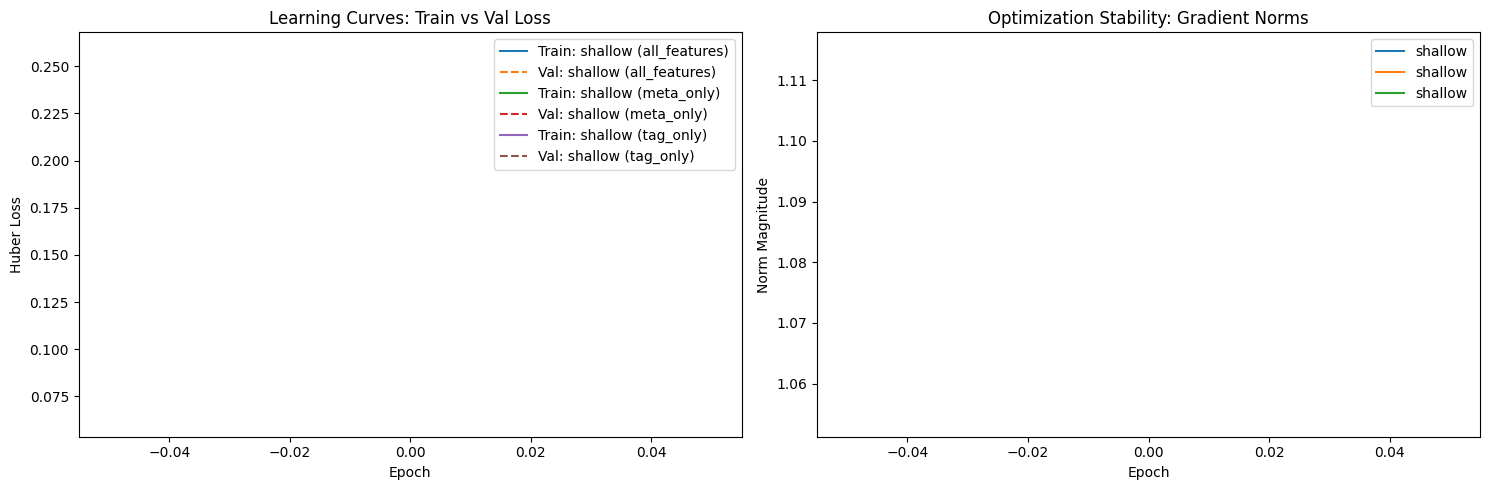

In [3]:
from src.visualizations import plot_experiment_results
s = load_settings()

plot_experiment_results(s.results_dir)
